In [16]:
# ICVul
import pandas as pd

# Load the datasets
df_labels = pd.read_csv('../data/intermediate/commits_icvul.csv')
df_metrics = pd.read_csv('../data/intermediate/churn_icvul_semantic.csv')

# Merge the dataframes
df_vuln = pd.merge(
    df_labels.drop(columns=['commit_role'], errors='ignore'), 
    df_metrics, 
    on='commit_id',
    how='inner',
)

df_vuln['lines_added'] = df_vuln['lines_added']
df_vuln['lines_removed'] = df_vuln['lines_removed']
df_vuln['lines_modified'] = df_vuln['lines_modified']

df_vuln['Dataset'] = 'Vulnerability'
df_vuln['Type'] = df_vuln['commit_role'].map({'VIC': 'Inducing', 'VFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']
stats = df_vuln.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Vulnerability Statistics (ICVul):")
print(stats.round(2))

Vulnerability Statistics (ICVul):
            lines_added                lines_removed                \
                 median     mean count        median    mean count   
commit_role                                                          
VFC                 5.0    13.23   314           0.0   24.52   314   
VIC                33.0  1053.52   649           5.0  125.39   649   

            lines_modified                
                    median    mean count  
commit_role                               
VFC                    1.0    3.80   314  
VIC                    8.0  268.05   649  


In [17]:
# KFC (Linux)
import pandas as pd

# Load the datasets
df_churn = pd.read_csv('../data/intermediate/churn_linux_semantic.csv')
df_labels = pd.read_csv('../data/intermediate/commits_dataset_linux.csv')

# Merge the datasets
# We drop 'commit_role' from df_churn so it doesn't conflict with df_labels
df_bug = pd.merge(
    df_labels, 
    df_churn.drop(columns=['commit_role'], errors='ignore'), 
    on='commit_id', 
    how='inner'
)

# 3. Define Metrics (Aligning with the Vulnerability dataset)
df_bug['lines_added'] = df_bug['lines_added']
df_bug['lines_removed'] = df_bug['lines_removed']
df_bug['lines_modified'] = df_bug['lines_modified']

df_bug['Dataset'] = 'Bug'
df_bug['Type'] = df_bug['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

# 4. Group by commit_role and calculate stats for all three metrics
metrics = ['lines_added', 'lines_removed', 'lines_modified']
stats = df_bug.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Bug Statistics (Linux KFC):")
print(stats.round(2))

# 5. Optional: Average Files Changed
files_stats = df_bug.groupby('commit_role')['files_changed'].mean()
print("\nAverage Files Changed:")
print(files_stats)

Bug Statistics (Linux KFC):
            lines_added               lines_removed               \
                 median    mean count        median   mean count   
commit_role                                                        
BFC                 1.0    5.57  5000           0.0   2.90  5000   
BIC                31.0  207.83  5000           1.0  32.68  5000   

            lines_modified             
                    median mean count  
commit_role                            
BFC                    1.0  2.0  5000  
BIC                    2.0  9.7  5000  

Average Files Changed:
commit_role
BFC    1.1144
BIC    3.0192
Name: files_changed, dtype: float64


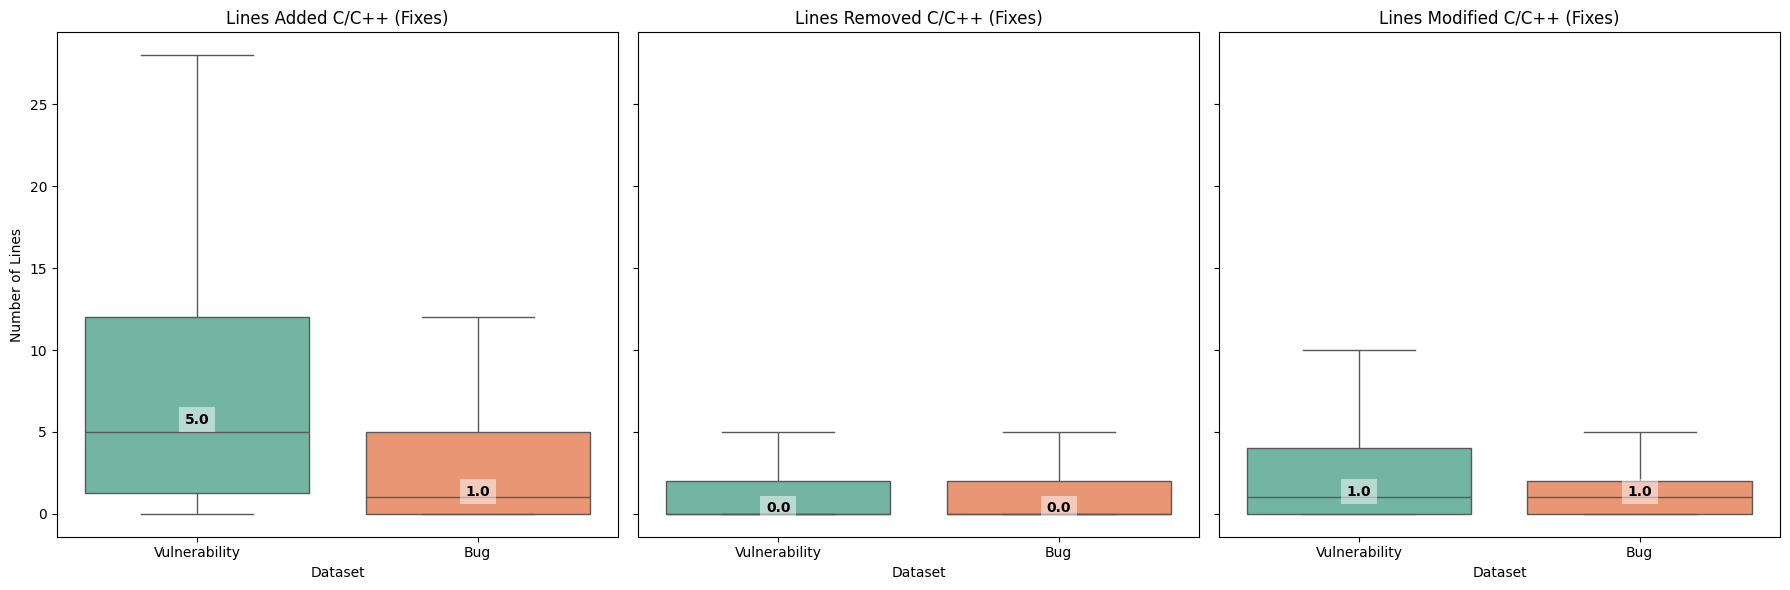

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_fixing = pd.concat([
    df_vuln[df_vuln['commit_role'] == 'VFC'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[df_bug['commit_role'] == 'BFC'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Fixes)', 'Lines Removed C/C++ (Fixes)', 'Lines Modified C/C++ (Fixes)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_fixing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    # We calculate medians grouped by Dataset for the specific metric
    medians = df_fixing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'{m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

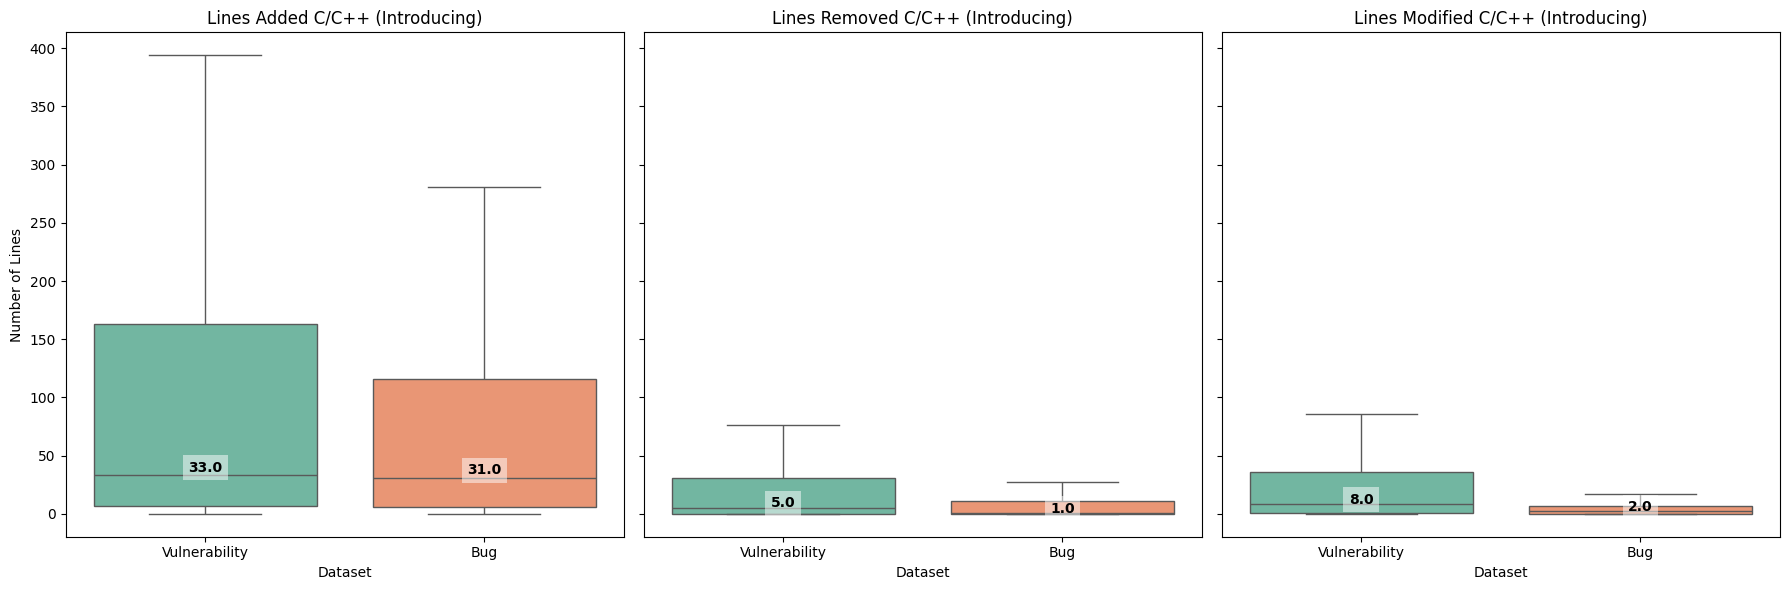

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_fixing = pd.concat([
    df_vuln[df_vuln['commit_role'] == 'VIC'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[df_bug['commit_role'] == 'BIC'][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Introducing)', 'Lines Removed C/C++ (Introducing)', 'Lines Modified C/C++ (Introducing)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_fixing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    # We calculate medians grouped by Dataset for the specific metric
    medians = df_fixing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'{m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

In [20]:
# TOSEM
import pandas as pd

# 1. Load the manual vulnerability dataset
df_vuln_java = pd.read_csv('../data/intermediate/churn_tosem_semantic.csv')

# 2. Group by Type (VFC/VIC) and calculate stats
metrics = ['lines_added', 'lines_removed', 'lines_modified']
vuln_stats = df_vuln_java.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Java Vulnerability Statistics (Manual TOSEM):")
print(vuln_stats.round(2))

# 3. Preparation for Plotting
# We make a copy specifically for the "Fixes" comparison plot
# and ensure the 'Group' label matches the style of your other sets
df_java_vfc_only = df_vuln_java[df_vuln_java['commit_role'] == 'VFC'].copy()
df_java_vic_only = df_vuln_java[df_vuln_java['commit_role'] == 'VIC'].copy()
df_java_vfc_only['Group'] = 'Java Vulnerability (Manual)'

Java Vulnerability Statistics (Manual TOSEM):
            lines_added                 lines_removed                \
                 median      mean count        median    mean count   
commit_role                                                           
VFC                17.0     90.80   177           1.0   36.94   177   
VIC               236.5  15066.55    94           2.0  651.76    94   

            lines_modified               
                    median   mean count  
commit_role                              
VFC                    3.0   9.23   177  
VIC                    6.0  42.03    94  


In [21]:
# DS_APACHE
import pandas as pd

df_bug_java = pd.read_csv('../data/intermediate/churn_ds_apache_semantic.csv')

df_bug_java['lines_added'] = df_bug_java['lines_added']
df_bug_java['lines_removed'] = df_bug_java['lines_deleted']
df_bug_java['lines_modified'] = df_bug_java['lines_modified']

df_bug_java['Dataset'] = 'Bug'
df_bug_java['Type'] = df_bug_java['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']
stats = df_bug_java.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

print("Bug Statistics (DS_APACHE):")
print(stats.round(2))

df_java_bfc_only = df_bug_java[df_bug_java['commit_role'] == 'BFC'].copy()
df_java_bic_only = df_bug_java[df_bug_java['commit_role'] == 'BIC'].copy()

files_stats = df_bug_java.groupby('commit_role')['files_changed'].mean()
print("\nAverage Files Changed:")
print(files_stats)

Bug Statistics (DS_APACHE):
            lines_added               lines_removed               \
                 median    mean count        median   mean count   
commit_role                                                        
BFC                 5.0   23.53   198           1.0  11.51   198   
BIC                52.0  293.20   285           8.0  89.78   285   

            lines_modified               
                    median   mean count  
commit_role                              
BFC                    2.0   8.17   198  
BIC                    8.0  49.32   285  

Average Files Changed:
commit_role
BFC    1.954545
BIC    9.547368
Name: files_changed, dtype: float64


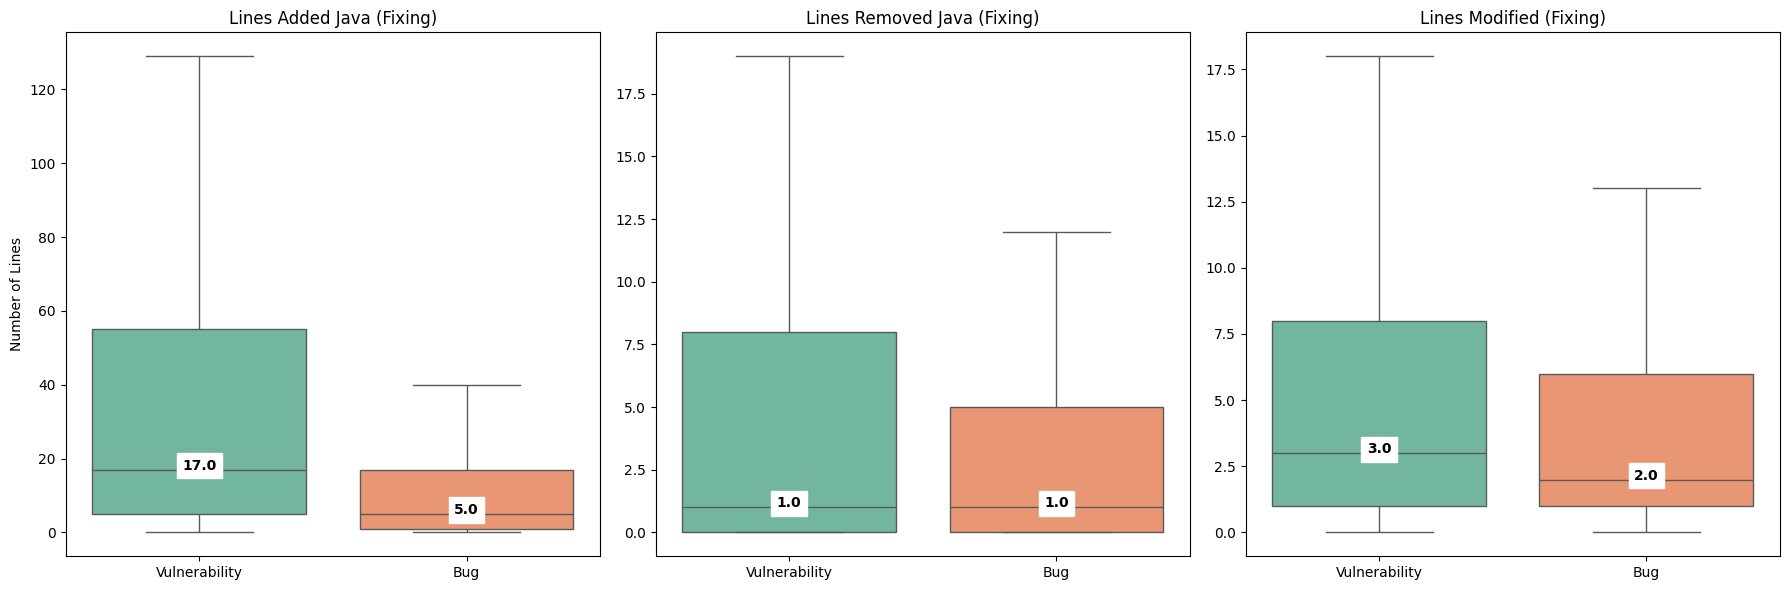

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixes
df_v = df_java_vfc_only.copy()
df_b = df_java_bfc_only.copy()

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Fixing)', 'Lines Removed Java (Fixing)', 'Lines Modified (Fixing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'{m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [23]:
# Load both restricted datasets
df_linux = pd.read_csv("../data/intermediate/commits_dataset_linux.csv")
df_icvul = pd.read_csv("../data/intermediate/commits_icvul_restricted.csv")

# Find the overlapping IDs
duplicates = set(df_linux['commit_id']).intersection(set(df_icvul['commit_id']))

print(f"Number of duplicate commits between C/C++ bug and vulnerability datasets: {len(duplicates)}")

Number of duplicate commits between C/C++ bug and vulnerability datasets: 0


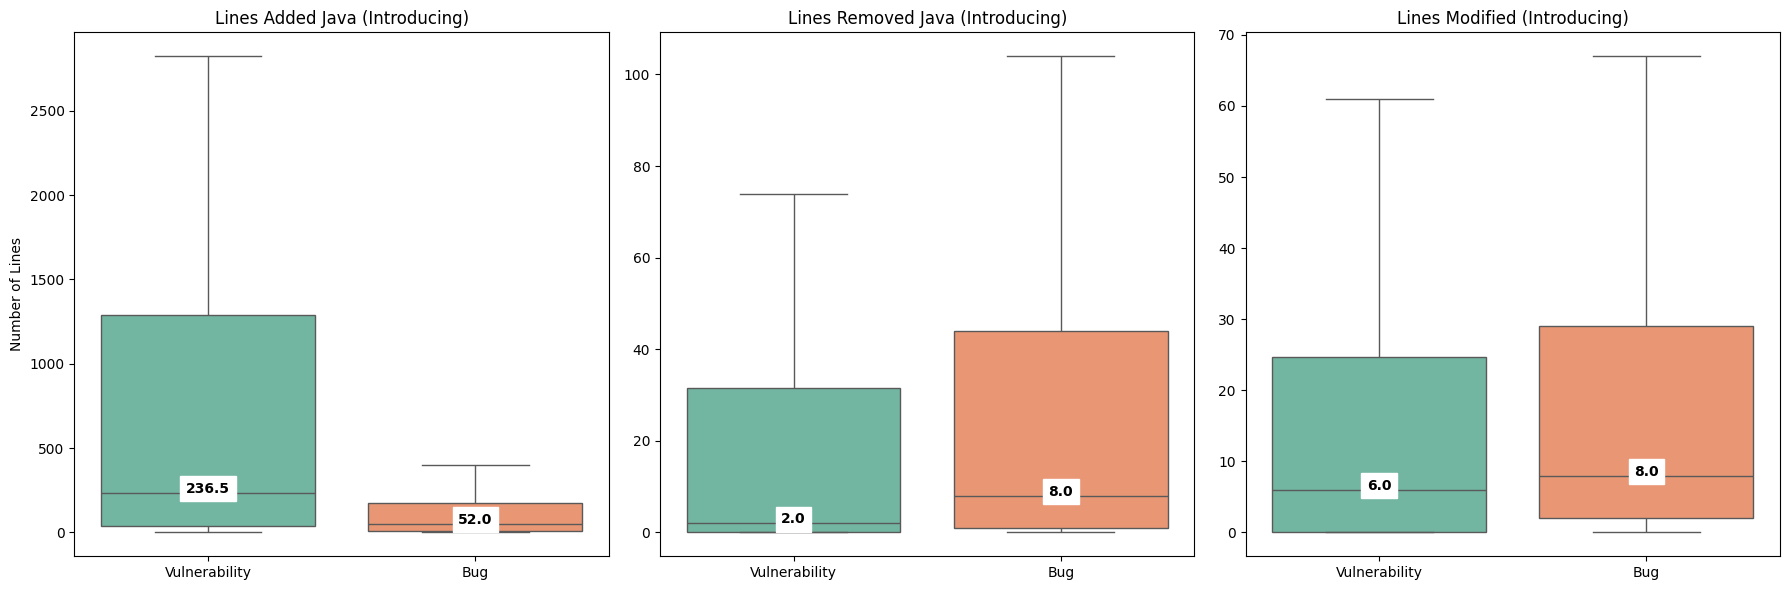

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixes
df_v = df_java_vic_only.copy()
df_b = df_java_bic_only.copy()

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Introducing)', 'Lines Removed Java (Introducing)', 'Lines Modified (Introducing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'{m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()